In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

from pathlib import Path

In [3]:
# carga tablon_analitico.pickle de datos/intermedios
df = pd.read_pickle(Path("../datos/intermedios/tablon_analitico.pickle"))

In [9]:
temp = df.loc[df.evento == "purchase", ['usuario','producto']].reset_index(drop=True)
temp

,usuario,producto
0,536128518,5887011
1,536128518,34767
2,536128518,34768
3,536128518,5584
4,536128518,5588612
...,...,...
127559,622065819,5659905
127560,622065819,5659911
127561,622065819,5697535
127562,622065819,5699414


In [13]:
# Sobre temp crea una lista con los 100 productos mas comprados
top_100_productos = temp['producto'].value_counts().head(100).index.tolist()
top_100_productos

[5809910,
 5854897,
 5700037,
 5304,
 5751422,
 5802432,
 5809912,
 5815662,
 5751383,
 5792800,
 5849033,
 5686925,
 5700046,
 5528035,
 5833330,
 5809911,
 5816170,
 5687151,
 5729864,
 5843836,
 5013,
 5759492,
 5622677,
 5833334,
 5800788,
 5793704,
 5561044,
 5700035,
 5549834,
 5862943,
 5587740,
 5670733,
 5783987,
 5789668,
 5615144,
 5761411,
 5833326,
 4958,
 4497,
 5773361,
 5817702,
 5776130,
 5773605,
 5857360,
 4938,
 5809871,
 5848909,
 5700039,
 5759279,
 5814046,
 5649219,
 5759491,
 5816166,
 5528034,
 5809297,
 5693501,
 5723529,
 5773606,
 5842141,
 5677043,
 5688124,
 5754853,
 5751742,
 5816172,
 5889300,
 5528051,
 5857007,
 5784897,
 5793703,
 5763238,
 5790563,
 5815730,
 5833325,
 5622687,
 5848387,
 5835924,
 5810157,
 5526,
 5836522,
 5565820,
 4768,
 5585656,
 5824810,
 5550302,
 5585658,
 4600,
 5816169,
 5854812,
 5810480,
 5742957,
 5844894,
 5833318,
 5855332,
 5724230,
 5809303,
 5749149,
 5835859,
 5749720,
 5862564,
 5833335]

In [15]:
# filtra temp para quedarte solo con los productos que estan en top_100_productos
temp_top = temp.loc[temp['producto'].isin(top_100_productos)].reset_index(drop=True)
temp_top

,usuario,producto
0,536128518,5815662
1,465338762,5817702
2,555497689,5649219
3,539216862,5854897
4,507864835,5622687
...,...,...
14211,582074095,5759491
14212,435564251,5802432
14213,617695004,5759491
14214,439781446,5742957


In [16]:
# Pivota producto a columna y usuario a filas y las celdas tendran el conteo de veces el usuario compro el producto
matriz_usuario_item = temp_top.pivot_table(index='usuario', columns='producto', aggfunc='size', fill_value=0)
matriz_usuario_item

producto,4497,4600,4768,4938,4958,5013,5304,5526,5528034,5528035,...,5848909,5849033,5854812,5854897,5855332,5857007,5857360,5862564,5862943,5889300
usuario,,,,,,,,,,,,,,,,,,,,,
25392526,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50748978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
74332980,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
80577370,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
88211255,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621646584,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
621788730,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
621925941,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
# Calcula la matriz de similaridad item-item usando distancia euclídea
from sklearn.metrics.pairwise import euclidean_distances

# Transpone la matriz para que los productos sean a filas
matriz_item_usuario = matriz_usuario_item.T

# Calcula la matriz de distancia euclídea entre los productos
similaridad_item = euclidean_distances(matriz_item_usuario)

# Convierte a DataFrame para facilitar su manejo
similaridad_item_df = pd.DataFrame(similaridad_item, index=matriz_item_usuario.index, columns=matriz_item_usuario.index)

# Guarda la matriz de similaridad item-item como pickle en datos/procesados
similaridad_item_df.to_pickle(Path("../datos/procesados/similaridad_item.pickle"))

In [43]:
# Carga similaridad_item_df desde pickle desde datos/procesados
similaridad_item_df = pd.read_pickle(Path("../datos/procesados/similaridad_item.pickle"))
similaridad_item_df

producto,4497,4600,4768,4938,4958,5013,5304,5526,5528034,5528035,...,5848909,5849033,5854812,5854897,5855332,5857007,5857360,5862564,5862943,5889300
producto,,,,,,,,,,,,,,,,,,,,,
4497,0.000000,14.422205,14.491377,15.620499,15.905974,17.578396,23.388031,15.231546,16.155494,20.297783,...,15.716234,24.454039,14.966630,26.095977,15.297059,15.066519,15.779734,15.165751,16.401219,15.329710
4600,14.422205,0.000000,10.677078,14.491377,14.594520,16.462078,22.693611,13.928388,14.866069,19.697716,...,14.387495,23.874673,13.490738,25.748786,13.784049,13.601471,14.456832,13.856406,14.730920,13.892444
4768,14.491377,10.677078,0.000000,14.560220,14.730920,16.278821,22.737634,14.000000,14.933185,19.748418,...,14.177447,24.000000,13.266499,25.632011,13.856406,13.747727,14.387495,13.856406,14.798649,14.106736
4938,15.620499,14.491377,14.560220,0.000000,15.524175,16.031220,22.956481,14.764823,15.652476,20.248457,...,15.132746,24.166092,14.352700,25.865034,14.764823,14.594520,15.459625,14.966630,15.716234,15.132746
4958,15.905974,14.594520,14.730920,15.524175,0.000000,17.492856,22.271057,15.329710,15.811388,20.322401,...,15.491933,24.351591,14.662878,26.153394,14.866069,14.966630,15.937377,15.264338,16.124515,15.033296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5857007,15.066519,13.601471,13.747727,14.594520,14.966630,16.792856,22.803509,14.594520,15.099669,19.621417,...,14.491377,23.979158,13.892444,25.612497,14.317821,0.000000,14.832397,14.456832,15.165751,14.422205
5857360,15.779734,14.456832,14.387495,15.459625,15.937377,16.062378,23.237900,15.394804,16.124515,20.322401,...,15.427249,23.853721,14.730920,25.455844,15.198684,14.832397,0.000000,13.747727,16.186414,15.427249
5862564,15.165751,13.856406,13.856406,14.966630,15.264338,15.716234,22.912878,14.696938,15.394804,19.899749,...,15.000000,23.323808,14.000000,25.119713,14.352700,14.456832,13.747727,0.000000,15.394804,14.662878


In [ ]:
def recomendar_productos(productos_id, matriz_similitud = similaridad_item_df, n=5):

    # Filtra solo los productos que esten en la matriz
    productos_validos = [prod for prod in productos_id if prod in matriz_similitud.index]
    if not productos_validos:
        raise ValueError("Ninguno de los productos proporcionados se encuentra en la matriz de similitud.")
    # Calcula la distancia media de cada producto respecto a los productos de entrada
    distancia_media = matriz_similitud.loc[productos_validos].mean(axis=0)
    # Ecluye los productos de entrada
    distancia_media = distancia_media.drop(index=productos_validos)
    # Ordena por distancia creciente y devuelve los n productos mas similares
    similares = distancia_media.sort_values().iloc[:n]
    return similares.index.tolist()


In [53]:
recomendar_productos([5815662,5649219,5622687])

[5835859, 5833335, 5749149, 5833318, 5824810]

In [41]:
temp_top.head()

,usuario,producto
0,536128518,5815662
1,465338762,5817702
2,555497689,5649219
3,539216862,5854897
4,507864835,5622687


In [56]:
# Filtramos solo eventos de compra
compras = df.loc[df.evento == 'purchase', ['usuario', 'producto', 'fecha_sin_hora']].reset_index(drop=True)

# Renombramos para comodidad
compras = compras.rename(columns={'fecha_sin_hora': 'fecha'})

# Convertimos fecha a datetime
compras['fecha'] = pd.to_datetime(compras['fecha'])

# Separamos train y test
train = compras[compras['fecha'] < '2020-02-01']
test = compras[compras['fecha'] >= '2020-02-01']

print(f"Train: {len(train)} compras de {train['usuario'].nunique()} usuarios")
print(f"Test:  {len(test)} compras de {test['usuario'].nunique()} usuarios")

# Usuarios evaluables
usuarios_comunes = set(train['usuario'].unique()) & set(test['usuario'].unique())
print(f"Usuarios evaluables (en train Y test): {len(usuarios_comunes)}")

Train: 102648 compras de 9186 usuarios
Test:  24916 compras de 2650 usuarios
Usuarios evaluables (en train Y test): 796


In [57]:
# Top 100 productos más comprados en TRAIN (no en todos los datos)
top_productos = train['producto'].value_counts().head(100).index.tolist()

# Filtramos train para quedarnos solo con esos productos
train_top = train[train['producto'].isin(top_productos)]

# Construimos la matriz usuario-item
matriz_usuario_item = train_top.pivot_table(
    index='usuario', 
    columns='producto', 
    aggfunc='size', 
    fill_value=0
)

print(f"Dimensiones de la matriz: {matriz_usuario_item.shape}")
print(f"Usuarios: {matriz_usuario_item.shape[0]}")
print(f"Productos: {matriz_usuario_item.shape[1]}")

Dimensiones de la matriz: (4209, 100)
Usuarios: 4209
Productos: 100


In [58]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import numpy as np

# Transponemos: queremos similitud entre productos, no entre usuarios
matriz_item_usuario = matriz_usuario_item.T

# 1. Distancia Euclídea (menor = más similar)
distancia_euclidea = euclidean_distances(matriz_item_usuario)
sim_euclidea = pd.DataFrame(distancia_euclidea, 
                             index=matriz_item_usuario.index, 
                             columns=matriz_item_usuario.index)

# 2. Similitud Coseno (mayor = más similar)
similitud_coseno = cosine_similarity(matriz_item_usuario)
sim_coseno = pd.DataFrame(similitud_coseno, 
                           index=matriz_item_usuario.index, 
                           columns=matriz_item_usuario.index)

# 3. Correlación de Pearson (mayor = más similar)
sim_pearson = matriz_item_usuario.T.corr()

print("Matrices calculadas:")
print(f"Euclídea:  {sim_euclidea.shape}")
print(f"Coseno:    {sim_coseno.shape}")
print(f"Pearson:   {sim_pearson.shape}")

Matrices calculadas:
Euclídea:  (100, 100)
Coseno:    (100, 100)
Pearson:   (100, 100)


In [59]:
def recomendar(producto_id, matriz_similitud, n=5, mayor_es_mejor=True):
    """
    Recomienda n productos similares a producto_id.
    
    mayor_es_mejor=True  → coseno y Pearson (ordenamos descendente)
    mayor_es_mejor=False → euclídea (ordenamos ascendente)
    """
    if producto_id not in matriz_similitud.index:
        return []
    
    similitudes = matriz_similitud.loc[producto_id]
    
    # Excluimos el propio producto
    similitudes = similitudes.drop(producto_id)
    
    if mayor_es_mejor:
        recomendados = similitudes.sort_values(ascending=False).head(n).index.tolist()
    else:
        recomendados = similitudes.sort_values(ascending=True).head(n).index.tolist()
    
    return recomendados

# Prueba rápida con un producto cualquiera
producto_prueba = matriz_item_usuario.index[0]
print(f"Producto de prueba: {producto_prueba}")
print(f"Euclídea: {recomendar(producto_prueba, sim_euclidea, mayor_es_mejor=False)}")
print(f"Coseno:   {recomendar(producto_prueba, sim_coseno,   mayor_es_mejor=True)}")
print(f"Pearson:  {recomendar(producto_prueba, sim_pearson,  mayor_es_mejor=True)}")

Producto de prueba: 4497
Euclídea: [4607, 4768, 4600, 5724230, 5550302]
Coseno:   [5700037, 4607, 5854897, 4768, 5723529]
Pearson:  [4607, 5700037, 4768, 4841, 4600]


In [62]:
def evaluar_metrica(matriz_similitud, mayor_es_mejor, n=5):
    """
    Calcula precisión@n promedio sobre los usuarios evaluables.
    Para cada usuario: recomienda n productos basándose en su historial (train)
    y comprueba cuántos coinciden con lo que compró realmente (test).
    """
    
    aciertos = []
    
    for usuario in usuarios_comunes:
        
        # Productos comprados en train (historial conocido)
        productos_train = set(
            train_top[train_top['usuario'] == usuario]['producto'].unique()
        )
        
        # Productos comprados en test (lo que queremos predecir)
        productos_test = set(
            test[test['usuario'] == usuario]['producto'].unique()
        )
        
        # Solo evaluamos si el usuario compró productos del top 100 en test
        productos_test_validos = productos_test & set(matriz_similitud.index)
        if not productos_test_validos:
            continue
        
        # Generamos recomendaciones basadas en cada producto del historial
        recomendados = set()
        for producto in productos_train:
            recs = recomendar(producto, matriz_similitud, n=n, mayor_es_mejor=mayor_es_mejor)
            recomendados.update(recs)
        
        # Excluimos productos que ya compró en train
        recomendados = recomendados - productos_train
        
        # Calculamos precisión: ¿cuántos recomendados compró realmente?
        if recomendados:
            precision = len(recomendados & productos_test_validos) / len(recomendados)
            aciertos.append(precision)
    
    return np.mean(aciertos) if aciertos else 0

# Evaluamos las tres métricas
precision_euclidea = evaluar_metrica(sim_euclidea, mayor_es_mejor=False)
precision_coseno   = evaluar_metrica(sim_coseno,   mayor_es_mejor=True)
precision_pearson  = evaluar_metrica(sim_pearson,  mayor_es_mejor=True)

print(f"Euclídea: {precision_euclidea:.4f}")
print(f"Coseno:   {precision_coseno:.4f}")
print(f"Pearson:  {precision_pearson:.4f}")

Euclídea: 0.0176
Coseno:   0.0429
Pearson:  0.0398


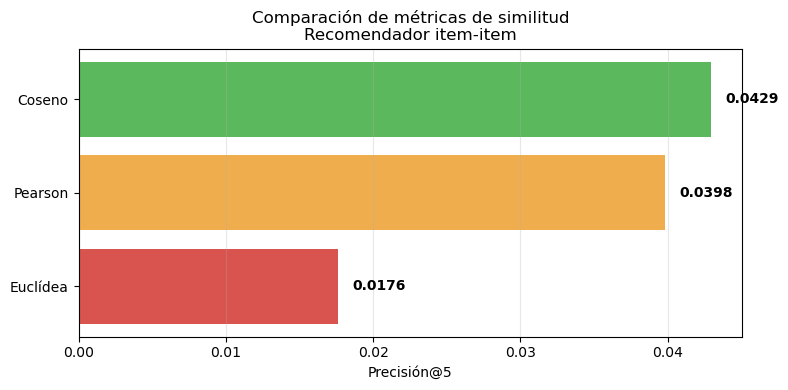

In [61]:
resultados = pd.DataFrame({
    'metrica': ['Euclídea', 'Coseno', 'Pearson'],
    'precision': [precision_euclidea, precision_coseno, precision_pearson]
}).sort_values('precision', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(resultados['metrica'], resultados['precision'], 
               color=['#d9534f', '#f0ad4e', '#5cb85c'])

# Etiquetas
for bar, val in zip(bars, resultados['precision']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontweight='bold')

ax.set_xlabel('Precisión@5')
ax.set_title('Comparación de métricas de similitud\nRecomendador item-item')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()